## 7CS070/UZ2: Concepts & Technologies of Artificial Intelligence

### Assessment Task 2 - Classification - Algorithm 2: Support Vector Machine (SVM)

- **Module:** 7CS070/UZ2: Concepts & Technologies of Artificial Intelligence
- **Author:** Santiago Cruz | **ID:** 2584023
- **Dataset:** NYSE: Oracle (`ORCL`), Daily Bars, 1986-2026 (TradingView export)
- **Task:** Predict next-day price direction (Up/Down) for `ORCL` using a Support Vector Machine.

**Approach.** Task 1 tried to predict the exact *size* of tomorrow's return and found almost no
usable signal in these eight technical indicators. Here we ask an easier version of the same
question: forget the size, can we at least predict the *direction* (up or down)? Features are
scaled first, since the SVM's RBF kernel is distance-based internally.

A second, independent notebook (2584023_Task2_Algo1.ipynb) applies KNN to the identical
problem; the written report compares both. Full referenced discussion is in the accompanying
written report - this notebook is the working code only.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

print('Libraries loaded.')

Libraries loaded.


### 1. Load and Clean the Data

This uses the identical cleaning pipeline as Task 1, applied to the same `ORCL` daily OHLC and
technical-indicator export: the `time` column is parsed to a proper datetime index, sorted
chronologically, checked for duplicates, and every price/indicator column is coerced to a numeric
type. Keeping the two tasks' preprocessing identical means any difference in downstream results
comes from the modelling choices (regression vs. classification, algorithm choice), not from
inconsistent data handling between the two notebooks.

In [2]:
# Load the ORCL daily OHLC + indicator export
orcl_1d_data = pd.read_csv('NYSE_BATS_ORCL_1D.csv')
orcl_1d_data['time'] = pd.to_datetime(orcl_1d_data['time'], errors='coerce')
orcl_1d_data = orcl_1d_data.dropna(subset=['time']).drop_duplicates().sort_values('time').set_index('time')

numeric_cols = ['open', 'high', 'low', 'close', 'SMA_756_Close', 'SMA_504_Close', 'SMA_252_Close',
                 'SMA_125_Close', 'SMA_63_Close', 'SMA_21_Close', 'TSI_25_13_13', 'TSI_Signal_13',
                 'RSI_25_Close', 'RSI_SMA_14']
for col in numeric_cols:
    orcl_1d_data[col] = pd.to_numeric(orcl_1d_data[col], errors='coerce')

print('Shape:', orcl_1d_data.shape)
orcl_1d_data.tail()

Shape: (10185, 18)


,open,high,low,close,SMA_756_Close,SMA_VWMA_756,SMA_504_Close,SMA_VWMA_504,SMA_252_Close,SMA_125_Close,SMA_63_Close,SMA_21_Close,TSI_25_13_13,TSI_Signal_13,RSI_25_Close,RSI_SMA_14,New_Moon,Full_Moon
time,,,,,,,,,,,,,,,,,,
2026-08-17,148.450,150.40,145.50,146.65,163.106349,162.796656,185.401309,185.173918,196.041071,161.88480,162.534921,135.714286,5.976252,-8.324582,48.864477,47.214831,0,0
2026-08-18,143.250,146.00,142.35,142.79,163.145675,162.825287,185.418234,185.189188,195.622460,161.77776,161.839365,136.733810,5.052806,-6.413526,47.291485,48.064536,0,0
2026-08-19,142.695,146.08,137.43,143.81,163.183029,162.869739,185.434524,185.215177,195.204762,161.67592,161.241746,137.531905,4.545954,-4.847886,47.754424,48.588301,0,0
2026-08-20,144.300,145.92,141.02,142.07,163.215807,162.904020,185.444722,185.236814,194.837500,161.62784,160.510159,138.304762,3.688181,-3.628448,47.020571,48.980040,0,0
2026-08-21,143.715,148.35,142.60,146.47,163.256984,162.955902,185.462579,185.271016,194.485952,161.66912,159.822857,139.563333,4.042427,-2.532609,49.081685,49.135719,0,0


#### 1.1 Price History (Context)

The same 40-year context chart as Task 1. It is worth remembering while reading the rest of this
notebook that `ORCL` has spent most of this history in a long-run uptrend - which matters for
Section 2.1 below, since it means "tomorrow closes higher" is not necessarily a 50/50 coin flip
over the full history even before any model is built.

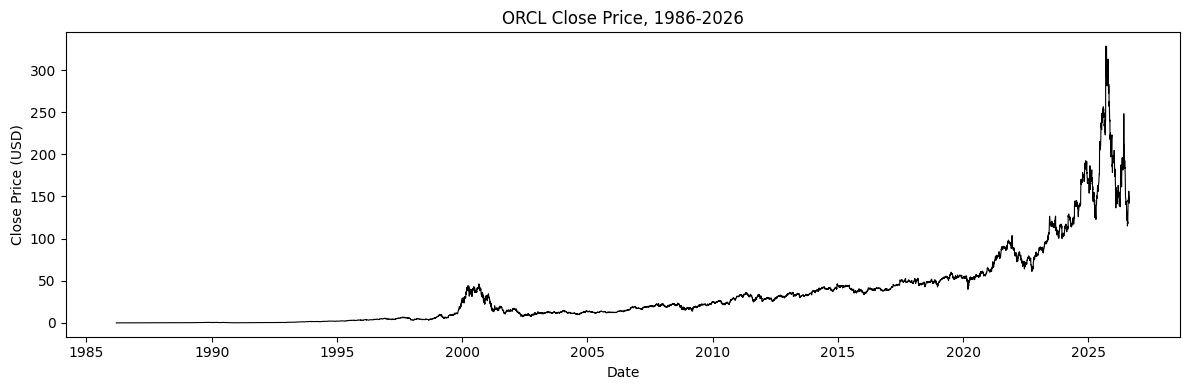

,open,high,low,close
count,10185.000,10185.000,10185.000,10185.000
mean,33.669,34.113,33.206,33.657
std,45.350,45.999,44.569,45.269
min,0.042,0.044,0.040,0.042
25%,3.620,3.685,3.528,3.604
50%,18.690,18.980,18.370,18.730
75%,42.000,42.500,41.590,42.060
max,330.340,345.720,312.090,328.330


In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(orcl_1d_data.index, orcl_1d_data['close'], color='black', linewidth=0.8)
ax.set_title('ORCL Close Price, 1986-2026')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
plt.tight_layout()
plt.show()

orcl_1d_data[['open', 'high', 'low', 'close']].describe().round(3)

### 2. Feature Engineering

The same eight features as Task 1, built only from information available at the close of today
(day *t*):

- `return_1d` - today's percentage price change (momentum).
- `volatility_10d` - rolling standard deviation of the last 10 daily returns (recent turbulence).
- `dist_sma21`, `dist_sma63`, `dist_sma252` - percentage distance of today's close from its 21-,
  63- and 252-day moving averages (short/medium/long-term trend position).
- `rsi`, `tsi`, `tsi_signal` - the Relative Strength Index and True Strength Index oscillators.

The **target** here is different from Task 1: instead of predicting the exact next-day return,
`target_direction` collapses it to a binary label (1 = price closes higher tomorrow, 0 = it does
not). This is a strictly easier prediction problem than Task 1's regression - a model only needs
to get the *sign* right, not the *size* - which is exactly why it is worth trying separately even
though Task 1 found next to no linear signal in these features.

In [4]:
df = orcl_1d_data.copy()

df['return_1d'] = df['close'].pct_change()
df['volatility_10d'] = df['return_1d'].rolling(10).std()
df['dist_sma21'] = (df['close'] - df['SMA_21_Close']) / df['SMA_21_Close']
df['dist_sma63'] = (df['close'] - df['SMA_63_Close']) / df['SMA_63_Close']
df['dist_sma252'] = (df['close'] - df['SMA_252_Close']) / df['SMA_252_Close']
df['rsi'] = df['RSI_25_Close']
df['tsi'] = df['TSI_25_13_13']
df['tsi_signal'] = df['TSI_Signal_13']

# Target: did price close higher the next day? (binary classification)
df['next_return'] = df['close'].shift(-1) / df['close'] - 1
df['target_direction'] = (df['next_return'] > 0).astype(int)

feature_cols = ['return_1d', 'volatility_10d', 'dist_sma21', 'dist_sma63', 'dist_sma252', 'rsi', 'tsi', 'tsi_signal']
df = df.dropna(subset=feature_cols + ['target_direction']).copy()

print('Feature matrix shape:', df[feature_cols].shape)
print('\nClass balance:')
print(df['target_direction'].value_counts(normalize=True).round(3))

Feature matrix shape: (9934, 8)

Class balance:
target_direction
0    0.502
1    0.498
Name: proportion, dtype: float64


#### 2.1 Class Balance and Feature Distributions

Checking class balance before modelling matters for a very practical reason: if 90% of days were
"Up", a classifier could score 90% accuracy just by always predicting "Up" without learning
anything - which is exactly why the `Baseline` model in Section 5 exists as a sanity check.
`ORCL`'s long-run uptrend (Section 1.1) might suggest "Up" days should dominate, so it is worth
confirming that empirically rather than assuming it, alongside checking that the engineered
features have not produced any obviously broken values (e.g. from a division by zero).

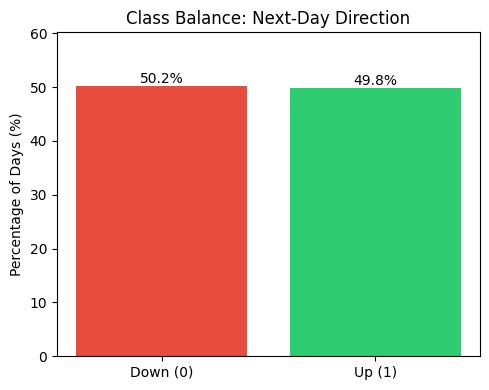

Feature descriptive statistics:
       return_1d  volatility_10d  dist_sma21  dist_sma63  dist_sma252  \
count  9934.0000       9934.0000   9934.0000   9934.0000    9934.0000   
mean      0.0011          0.0244      0.0083      0.0266       0.1174   
std       0.0292          0.0164      0.0683      0.1212       0.2756   
min      -0.2915          0.0029     -0.4473     -0.6132      -0.7173   
25%      -0.0122          0.0130     -0.0247     -0.0328      -0.0180   
50%       0.0000          0.0203      0.0084      0.0276       0.0886   
75%       0.0132          0.0319      0.0416      0.0841       0.2157   
max       0.4387          0.1474      0.3807      0.7117       1.8948   

             rsi        tsi  tsi_signal  
count  9934.0000  9934.0000   9934.0000  
mean     52.5874     5.3593      5.3890  
std       8.4988    19.2070     17.2847  
min      24.4961   -54.0661    -50.3929  
25%      46.6011    -8.0541     -6.6210  
50%      52.9101     6.0199      6.0945  
75%      58.5068

In [5]:
class_pct = df['target_direction'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Down (0)', 'Up (1)'], class_pct.values, color=['#e74c3c', '#2ecc71'])
for bar, pct in zip(bars, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{pct:.1f}%', ha='center')
ax.set_title('Class Balance: Next-Day Direction')
ax.set_ylabel('Percentage of Days (%)')
ax.set_ylim(0, max(class_pct.values) + 10)
plt.tight_layout()
plt.show()

print('Feature descriptive statistics:')
print(df[feature_cols].describe().round(4))

### 3. Quick Visual Check: Which Features Actually Relate to the Target?

Same idea as Task 1: check, before modelling, which features look related to next-day direction
and which look close to noise. Since the target here is binary (0/1), a Pearson correlation
against it is equivalent to a point-biserial correlation - a standard way to screen features
against a binary outcome. As in Task 1, this step directly informs the "how would you improve the
model" discussion required in the written report.

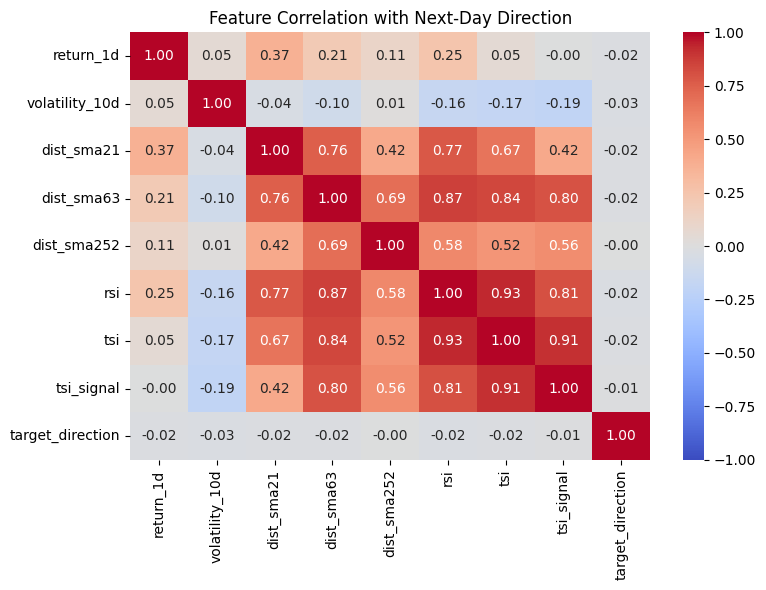

Correlation of each feature with the target, sorted by strength:
volatility_10d   -0.028855
rsi              -0.023591
dist_sma21       -0.021538
dist_sma63       -0.017986
tsi              -0.016725
return_1d        -0.016587
tsi_signal       -0.010405
dist_sma252      -0.000077
Name: target_direction, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[feature_cols + ['target_direction']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation with Next-Day Direction')
plt.tight_layout()
plt.show()

print('Correlation of each feature with the target, sorted by strength:')
print(corr['target_direction'].drop('target_direction').sort_values(key=abs, ascending=False))

#### 3.1 Do the Top Features Actually Separate the Classes?

A correlation coefficient is a single summary number; it is worth also looking directly at the
distributions. The boxplots below show the 3 features with the strongest (still weak)
correlation to the target, split by whether the next day went Up or Down. If a feature separated
the classes well, its two boxes would sit at clearly different heights.

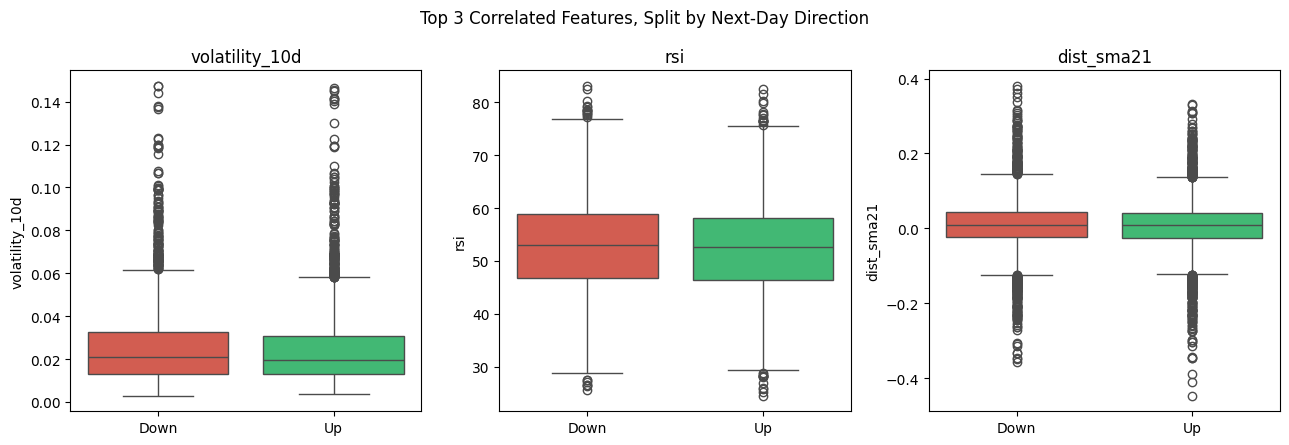

If a feature separated the two classes well, its Up/Down boxes above would sit at clearly different levels -
here they overlap almost completely, consistent with the near-zero correlations found above.


In [7]:
top3_features = corr['target_direction'].drop('target_direction').abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, feat in zip(axes, top3_features):
    sns.boxplot(data=df, x='target_direction', y=feat, ax=ax, hue='target_direction',
                palette={0: '#e74c3c', 1: '#2ecc71'}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Down', 'Up'])
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Top 3 Correlated Features, Split by Next-Day Direction')
plt.tight_layout()
plt.show()

print('If a feature separated the two classes well, its Up/Down boxes above would sit at clearly different levels -')
print('here they overlap almost completely, consistent with the near-zero correlations found above.')

#### 3.2 Checking for Multicollinearity Among Features

The same eight features used in Task 1 are used here, so the same concern applies: several of
them are constructed from overlapping information (three different distance-from-moving-average
features, and three momentum oscillators that are mathematically related to each other), which
means some may be redundant for modelling purposes even before we ask whether any of them predict
the target well. Feature pairs with |correlation| above 0.5 are listed explicitly below, following
the same rule of thumb used in Task 1 (Hastie, Tibshirani and Friedman, 2009).

In [8]:
feature_corr = df[feature_cols].corr()

pairs = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool)).stack()
high_corr_pairs = pairs[pairs.abs() > 0.5].sort_values(key=abs, ascending=False)

if len(high_corr_pairs) > 0:
    print('Feature pairs with |correlation| > 0.5 (candidates for redundancy):')
    print(high_corr_pairs.round(3))
else:
    print('No feature pair exceeds |correlation| = 0.5 - multicollinearity is not a major concern here.')

feature_corr.round(2)

Feature pairs with |correlation| > 0.5 (candidates for redundancy):
rsi          tsi            0.931
tsi          tsi_signal     0.914
dist_sma63   rsi            0.865
             tsi            0.837
rsi          tsi_signal     0.806
dist_sma63   tsi_signal     0.802
dist_sma21   rsi            0.774
             dist_sma63     0.756
dist_sma63   dist_sma252    0.692
dist_sma21   tsi            0.670
dist_sma252  rsi            0.584
             tsi_signal     0.561
             tsi            0.523
dtype: float64


,return_1d,volatility_10d,dist_sma21,dist_sma63,dist_sma252,rsi,tsi,tsi_signal
return_1d,1.00,0.05,0.37,0.21,0.11,0.25,0.05,-0.00
volatility_10d,0.05,1.00,-0.04,-0.10,0.01,-0.16,-0.17,-0.19
dist_sma21,0.37,-0.04,1.00,0.76,0.42,0.77,0.67,0.42
dist_sma63,0.21,-0.10,0.76,1.00,0.69,0.87,0.84,0.80
dist_sma252,0.11,0.01,0.42,0.69,1.00,0.58,0.52,0.56
rsi,0.25,-0.16,0.77,0.87,0.58,1.00,0.93,0.81
tsi,0.05,-0.17,0.67,0.84,0.52,0.93,1.00,0.91
tsi_signal,-0.00,-0.19,0.42,0.80,0.56,0.81,0.91,1.00


### 4. Train/Test Split and Feature Scaling

A chronological split, as in Task 1 (never random, for the same look-ahead-leakage reason): the
first 80% of rows by date form the training set, the final 20% form the test set. This algorithm
is **distance-based**, so features must be scaled to comparable ranges first. Without scaling, a
feature like `dist_sma252` (typical values around +/-0.3) would be swamped by a feature like `rsi`
(values 0-100) purely because of its numeric scale, not because `rsi` is more informative;
`StandardScaler` rescales every feature to zero mean and unit variance so each one contributes on
equal footing. Note that the scaler is fit **only on the training data** and then applied to the
test data, never the reverse - fitting it on the full dataset would leak information about the
test period's distribution into training.

In [9]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['target_direction']
X_test, y_test = test_df[feature_cols], test_df['target_direction']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)')
print(f'Test:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)')

Train: 1987-03-10 to 2018-09-24 (7947 rows)
Test:  2018-09-25 to 2026-08-21 (1987 rows)


### 5. Baseline

`DummyClassifier(strategy='most_frequent')` always predicts whichever class was more common in
the training data, regardless of the input features - it uses no information at all beyond the
class counts. Any classifier that cannot beat this is not actually learning anything useful from
the features; it is the minimum bar this algorithm must clear.

In [10]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
print('Baseline accuracy:', round(accuracy_score(y_test, baseline_pred), 4))
print('Baseline MCC:', round(matthews_corrcoef(y_test, baseline_pred), 4))

Baseline accuracy: 0.4751
Baseline MCC: 0.0


### 6. Algorithm: Support Vector Machine (SVM)

An SVM looks for the boundary that separates the two classes with the largest possible margin -
the widest possible gap - between them (Cortes and Vapnik, 1995). The `rbf` (radial basis
function) kernel used here allows that boundary to be a curved surface rather than a straight
line, by implicitly mapping the features into a higher-dimensional space where a straight
separating boundary in that space corresponds to a curved one in the original feature space (the
"kernel trick" - this happens mathematically without ever explicitly computing the
higher-dimensional coordinates). `C=1.0` controls the trade-off between a wider margin and
tolerating some misclassified training points; `gamma='scale'` sets how far the influence of a
single training example reaches, scaled automatically to the data.

In [11]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
svm_bal_acc = balanced_accuracy_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred, average='macro')
svm_mcc = matthews_corrcoef(y_test, svm_pred)
print(f'SVM -> Accuracy: {svm_acc:.4f} | Balanced Accuracy: {svm_bal_acc:.4f} | F1 (macro): {svm_f1:.4f} | MCC: {svm_mcc:.4f}')
print(classification_report(y_test, svm_pred, target_names=['Down', 'Up']))

SVM -> Accuracy: 0.5058 | Balanced Accuracy: 0.5057 | F1 (macro): 0.5054 | MCC: 0.0114
              precision    recall  f1-score   support

        Down       0.48      0.50      0.49       944
          Up       0.53      0.51      0.52      1043

    accuracy                           0.51      1987
   macro avg       0.51      0.51      0.51      1987
weighted avg       0.51      0.51      0.51      1987



#### 6.1 ROC Curve and AUC

Accuracy and balanced accuracy both depend on a single, fixed decision threshold (predict "Up" if
the model's estimated probability exceeds 0.5). The ROC (Receiver Operating Characteristic) curve
instead plots the True Positive Rate against the False Positive Rate across *every possible*
threshold, and the AUC (Area Under the Curve) summarises the whole curve in one number: 1.0 is a
perfect classifier, 0.5 is exactly what random guessing would achieve on average.

SVM ROC-AUC: 0.5032


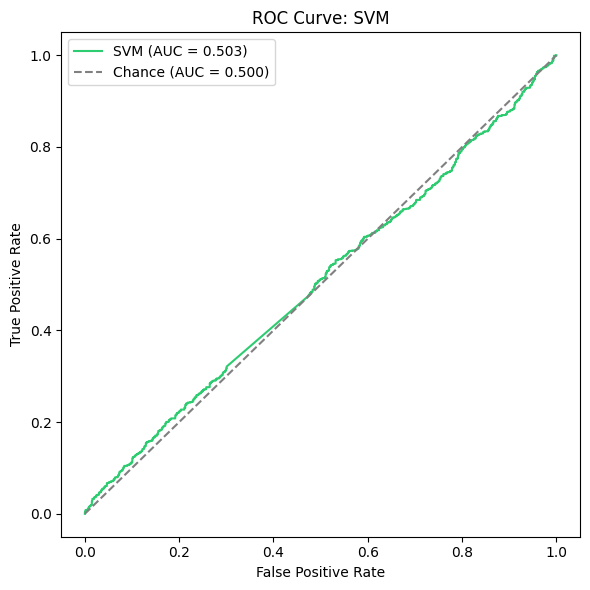

In [12]:
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_proba)
svm_auc = roc_auc_score(y_test, svm_proba)
print(f'SVM ROC-AUC: {svm_auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.3f})', color='#2ecc71')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance (AUC = 0.500)')
ax.set_title('ROC Curve: SVM')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

### 7. Confusion Matrix

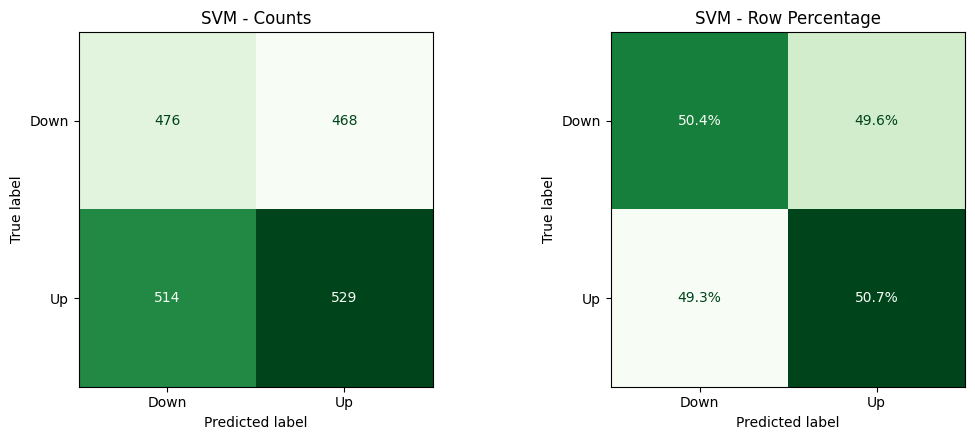

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred), display_labels=['Down', 'Up']).plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('SVM - Counts')
ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred, normalize='true'), display_labels=['Down', 'Up']).plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='.1%')
axes[1].set_title('SVM - Row Percentage')
plt.tight_layout()
plt.show()

### 8. Cross-Validated Performance (More Robust Than a Single Split)

As in Task 1, a single 80/20 split gives one noisy estimate of test performance. `TimeSeriesSplit`
creates 5 successive, still-chronological train/test folds and we average accuracy and balanced
accuracy across all 5. The scaler is refit separately inside each fold (using only that fold's
training rows) to avoid leaking information across folds, exactly as in the main pipeline above.

In [14]:
from sklearn.model_selection import TimeSeriesSplit

X_all = df[feature_cols]
y_all = df['target_direction']

tscv = TimeSeriesSplit(n_splits=5)
cv_acc, cv_bal_acc = [], []

for train_idx, test_idx in tscv.split(X_all):
    X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]

    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr)
    X_te_scaled = fold_scaler.transform(X_te)

    fold_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(X_tr_scaled, y_tr)
    pred = fold_svm.predict(X_te_scaled)
    cv_acc.append(accuracy_score(y_te, pred))
    cv_bal_acc.append(balanced_accuracy_score(y_te, pred))

print('5-fold TimeSeriesSplit cross-validation for SVM:')
print(f'Mean CV Accuracy:          {np.mean(cv_acc):.4f} (std {np.std(cv_acc):.4f})')
print(f'Mean CV Balanced Accuracy: {np.mean(cv_bal_acc):.4f} (std {np.std(cv_bal_acc):.4f})')

5-fold TimeSeriesSplit cross-validation for SVM:
Mean CV Accuracy:          0.5123 (std 0.0109)
Mean CV Balanced Accuracy: 0.5117 (std 0.0122)


### Summary

On the held-out test set, SVM achieves Accuracy = 0.5058, Balanced Accuracy = 0.5057, F1 (macro)
= 0.5054, ROC-AUC = 0.5032 and MCC = 0.0114 - all essentially at the chance level, though every
metric edges out KNN's equivalent. Section 3's correlation heatmap and Section 3.1's boxplots show
none of the eight features separate the Up/Down classes meaningfully. See the accompanying
written report (Task 2) for the full comparison against KNN in 2584023_Task2_Algo1.ipynb,
references, and suggested improvements.